# Urban Mobility Prediction: Nextbike System Analysis

**Course**: Applications in Data Analytics (Summer Semester 2026)  

**Institution**: Chair of Big Data Analytics in Transportation (BDA), TU Dresden  

**Heyao Lin 5343186**

**Chuhan Shu 5319793**

**Team Name: CH**

## Project Overview
This analysis addresses the urban mobility prediction task within Vienna's Nextbike system. The objective is to forecast the average number of available bikes at station levels in 30-minute intervals. The dataset comprises over eight months of operational data (September 2024 – April 2025). Accuracy is evaluated using the Root Mean Squared Logarithmic Error (RMSLE) metric. This document details the end-to-end workflow, including data preprocessing, feature engineering, model training, and performance evaluation.

## 1. Data Preprocessing
---
**Step 1: Initializing the Project & Data Loading**

The environment is initialized through the necessary library imports. Operational data is loaded, and temporal features are parsed into a standardized format to ensure consistency throughout the analysis.

In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import warnings
import matplotlib.pyplot as plt
import shap
warnings.filterwarnings('ignore')

print("[INFO] Initializing Bike Demand Prediction Pipeline...")

[INFO] Initializing Bike Demand Prediction Pipeline...


In [4]:
# 1. Load datasets

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Standardize timestamps

train_df['datetime_parsed'] = pd.to_datetime(train_df['datetime']).dt.tz_localize(None)
test_df['datetime_parsed'] = pd.to_datetime(test_df['datetime']).dt.tz_localize(None)
num_train = len(train_df)

# Apply Log transformation to target variable for RMSLE optimization

train_df['bikes_log'] = np.log1p(train_df['bikes'])
df_all = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)


## 2. Feature Engineering
---
**Step 2: Feature Engineering**

The quality of the predictive model is enhanced through comprehensive feature engineering. This process involves extracting temporal cycles, incorporating spatial coordinates, and deriving geographic relationships relative to central urban hubs. These features allow the model to capture mobility patterns such as commuting peaks and the spatial decay of bike demand.

In [5]:
# 2. Constructs a feature matrix for the bike demand model.

def build_master_features(df):
    features = pd.DataFrame()
    dt = df['datetime_parsed']
    
    # 2.1 Basic Spatial Position: Station coordinates
    features['station_number'] = df['station_number']
    features['lat'] = df['lat']
    features['lng'] = df['lng']
    
    # 2.2 Temporal Cycles: Sine and Cosine encoding for time periodicity
    features['hour'] = dt.dt.hour + dt.dt.minute / 60.0
    features['dayofweek'] = dt.dt.dayofweek
    features['month'] = dt.dt.month
    features['day'] = dt.dt.day
    features['dayofyear'] = dt.dt.dayofyear
    
    features['time_slot'] = dt.dt.hour * 2 + (dt.dt.minute / 30)
    features['slot_sin'] = np.sin(2 * np.pi * features['time_slot'] / 48)
    features['slot_cos'] = np.cos(2 * np.pi * features['time_slot'] / 48)
    features['dayofweek_sin'] = np.sin(2 * np.pi * features['dayofweek'] / 7)
    features['dayofweek_cos'] = np.cos(2 * np.pi * features['dayofweek'] / 7)
    
    # 2.3 Commute Pattern Marking
    features['is_weekend'] = features['dayofweek'].isin([5, 6]).astype(int)
    features['is_commute_peak'] = (((features['hour'] >= 7.5) & (features['hour'] <= 9.5)) | \
                                   ((features['hour'] >= 16.5) & (features['hour'] <= 18.5))) & (features['is_weekend'] == 0)
    features['is_commute_peak'] = features['is_commute_peak'].astype(int)
    
    # 2.4 Temperature Trend: Macro-trend based on monthly averages
    vienna_temp_map = {1: 3, 2: 5, 3: 10, 4: 15, 5: 21, 6: 25, 7: 27, 8: 27, 9: 21, 10: 14, 11: 8, 12: 4}
    base_temp = features['month'].map(vienna_temp_map)
    spring_trend = np.where(features['month'] == 4, (features['day'] - 15) * 0.2, 0)
    hour_effect = np.cos(2 * np.pi * (features['hour'] - 14) / 24) * 4.0
    features['estimated_temp'] = base_temp + spring_trend + hour_effect
    
    # 2.5 Spatial Proximity: Haversine distance calculation to urban hubs
    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        return 2 * np.arcsin(np.sqrt(np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2)) * 6371

    features['dist_to_center'] = haversine(df['lat'], df['lng'], 48.2082, 16.3738)
    features['dist_to_hbf'] = haversine(df['lat'], df['lng'], 48.1851, 16.3761)
    features['dist_to_prater'] = haversine(df['lat'], df['lng'], 48.2170, 16.4050)
    features['dist_to_wu'] = haversine(df['lat'], df['lng'], 48.2139, 16.4097)
    
    # 2.6 Non-linear Interaction Features
    features['center_dist_hour'] = features['dist_to_center'] * features['hour']
    features['hbf_dist_hour'] = features['dist_to_hbf'] * features['hour']
    features['dist_to_center_sq'] = features['dist_to_center'] ** 2
    features['temp_weekend_int'] = features['estimated_temp'] * features['is_weekend']
    
    return features

# 2.7 Generate the feature set
df_features = build_master_features(df_all)

## 3. Model A
---
**Step 3: Model A - Spatiotemporal Modeling**

Model A utilizes pure spatiotemporal features to establish a baseline. To ensure academic integrity and prevent data leakage, a strict time-series split is applied. Historical demand profiles (e.g., station-specific time-slot averages) are calculated exclusively on the training subset, ensuring that future information from the validation or test sets does not influence the training process.

In [6]:
# 3.1 Initialize model training and validation datasets

print("[INFO] Initiating time-series split...")

X_train_A_raw = df_features.iloc[:num_train].copy()
y_train_A = train_df['bikes_log'].values
X_test_A_raw = df_features.iloc[num_train:].copy()

# Define the splitting point for local validation
split_idx = int(num_train * 0.85)

# 3.2 Calculate station profiles safely to avoid data leakage
train_raw_part = X_train_A_raw.iloc[:split_idx].copy()
train_raw_part['bikes_log'] = y_train_A[:split_idx]

# Aggregate statistics for station-based demand
station_max_A = train_raw_part.groupby('station_number')['bikes_log'].max().reset_index().rename(columns={'bikes_log': 'station_max_capacity'})
slot_stats_A = train_raw_part.groupby(['station_number', 'time_slot'])['bikes_log'].agg(['mean', 'median', 'std']).reset_index()
slot_stats_A.columns = ['station_number', 'time_slot', 'hist_slot_mean', 'hist_slot_median', 'hist_slot_std']

weekend_slot_stats_A = train_raw_part.groupby(['station_number', 'is_weekend', 'time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
weekend_slot_stats_A.columns = ['station_number', 'is_weekend', 'time_slot', 'hist_wk_slot_mean', 'hist_wk_slot_median']

global_slot_stats_A = train_raw_part.groupby(['time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
global_slot_stats_A.columns = ['time_slot', 'global_slot_mean', 'global_slot_median']

# 3.3 Profile merging utility
def merge_profiles_safe(df, station_max, slot_stats, weekend_slot_stats, global_slot_stats):
    res = df.merge(station_max, on='station_number', how='left')
    res = res.merge(slot_stats, on=['station_number', 'time_slot'], how='left')
    res = res.merge(weekend_slot_stats, on=['station_number', 'is_weekend', 'time_slot'], how='left')
    res = res.merge(global_slot_stats, on=['time_slot'], how='left')
    
    # Fill missing values for cold-start stations with global averages
    res['hist_slot_mean'] = res['hist_slot_mean'].fillna(res['global_slot_mean'])
    res['hist_slot_median'] = res['hist_slot_median'].fillna(res['global_slot_median'])
    res['hist_wk_slot_mean'] = res['hist_wk_slot_mean'].fillna(res['hist_slot_mean'])
    res['hist_wk_slot_median'] = res['hist_wk_slot_median'].fillna(res['hist_slot_median'])
    
    res['enc_norm_mean'] = res['hist_slot_mean'] / (res['station_max_capacity'] + 1e-5)
    res['enc_wk_norm_mean'] = res['hist_wk_slot_mean'] / (res['station_max_capacity'] + 1e-5)
    return res

X_train_A_mapped = merge_profiles_safe(X_train_A_raw, station_max_A, slot_stats_A, weekend_slot_stats_A, global_slot_stats_A)

X_tr_A, y_tr_A = X_train_A_mapped.iloc[:split_idx], y_train_A[:split_idx]
X_va_A, y_va_A = X_train_A_mapped.iloc[split_idx:], y_train_A[split_idx:]

# Convert station_number to category type to optimize LightGBM's categorical feature splitting
X_tr_A['station_number'] = X_tr_A['station_number'].astype('category')
X_va_A['station_number'] = X_va_A['station_number'].astype('category')

# 3.4 Model configuration and training
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.015,
    'num_leaves': 31,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 150,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'n_jobs': -1,
    'verbose': -1
}

# Fit model using early stopping
pre_model_A = lgb.LGBMRegressor(n_estimators=4000, **lgb_params)
pre_model_A.fit(X_tr_A, y_tr_A, eval_set=[(X_va_A, y_va_A)], callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)])
best_iters_A = pre_model_A.best_iteration_


[INFO] Initiating time-series split...


To maximize predictive performance on the public test set, the model is retrained on the full historical dataset after hyperparameter optimization, ensuring the maximum possible utilization of available operational information.

In [7]:
# 3.5 Retrain Model A with 100% of the historical data for the final submission
print("[INFO] Re-calculating station profiles using 100% dataset for final submission...")

# Re-calculate station profiles on the complete dataset
station_max_total = X_train_A_raw.copy()
station_max_total['bikes_log'] = y_train_A
station_max_full = station_max_total.groupby('station_number')['bikes_log'].max().reset_index().rename(columns={'bikes_log': 'station_max_capacity'})
slot_stats_full = station_max_total.groupby(['station_number', 'time_slot'])['bikes_log'].agg(['mean', 'median', 'std']).reset_index()
slot_stats_full.columns = ['station_number', 'time_slot', 'hist_slot_mean', 'hist_slot_median', 'hist_slot_std']

weekend_stats_full = station_max_total.groupby(['station_number', 'is_weekend', 'time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
weekend_stats_full.columns = ['station_number', 'is_weekend', 'time_slot', 'hist_wk_slot_mean', 'hist_wk_slot_median']

global_stats_full = station_max_total.groupby(['time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
global_stats_full.columns = ['time_slot', 'global_slot_mean', 'global_slot_median']

# Map the global profiles to the training and test sets
X_train_A_full = merge_profiles_safe(X_train_A_raw, station_max_full, slot_stats_full, weekend_stats_full, global_stats_full)
X_test_A_full = merge_profiles_safe(X_test_A_raw, station_max_full, slot_stats_full, weekend_stats_full, global_stats_full)

X_train_A_full['station_number'] = X_train_A_full['station_number'].astype('category')
X_test_A = X_test_A_full.copy()
X_test_A['station_number'] = X_test_A['station_number'].astype('category')

# 3.6 Train final model with ensemble seeds to ensure robust predictions
seeds = [42, 2026]
sub_preds_A = np.zeros(len(X_test_A))
for seed in seeds:
    current_params = lgb_params.copy()
    current_params['random_state'] = seed
    model_A = lgb.LGBMRegressor(n_estimators=int(best_iters_A * 1.1), **current_params)
    model_A.fit(X_train_A_full, y_train_A)
    sub_preds_A += model_A.predict(X_test_A) / len(seeds)

# 3.7 Post-processing: Apply shrinkage and clipping to avoid overestimation
preds_log_shrinked_A = sub_preds_A * 0.84
final_preds_bikes_A = np.expm1(preds_log_shrinked_A)
final_preds_bikes_A = np.clip(final_preds_bikes_A, 0, None)
final_preds_bikes_A = np.power(final_preds_bikes_A, 0.978) 
test_max_capacity_val = np.expm1(X_test_A['station_max_capacity'].values)
final_preds_bikes_A = np.minimum(final_preds_bikes_A, test_max_capacity_val * 1.15)
final_preds_int_A = np.round(final_preds_bikes_A).astype(int)

# 3.8 Generate the final submission file
formatted_test_dt = test_df['datetime_parsed'].dt.strftime('%Y-%m-%d %H:%M:%S')
submission_A = pd.DataFrame({
    'id': formatted_test_dt + '_' + test_df['station_number'].astype(str),
    'bikes': final_preds_int_A
})
submission_A.to_csv('submission_public.csv', index=False)
print("[INFO] Model A final submission file generated: 'submission_public.csv' \n")

[INFO] Re-calculating station profiles using 100% dataset for final submission...
[INFO] Model A final submission file generated: 'submission_public.csv' 



## 4. Model B
---
**Step 4: Model B - Weather-Aware Modeling**

Model B extends the spatiotemporal approach by integrating meteorological data. To ensure a precise alignment between bike availability and weather conditions, a hourly-floor temporal alignment is implemented. This prevents potential data misalignment issues, allowing the model to capture the impact of environmental variables such as temperature, rain, and snowfall on urban mobility.

In [8]:
# 4.1 Temporal alignment and weather integration

print("[INFO] Aligning timestamps and integrating meteorological data...")

# Align bike data with hourly weather records using floor function
df_features['datetime_floor'] = train_df['datetime_parsed'].combine_first(test_df['datetime_parsed']).dt.floor('h')

try:
    # Load and preprocess weather data
    weather_df = pd.read_csv('Vienna-weather.csv', skiprows=2)
    weather_df.columns = [col.split(' ')[0].strip().lower() for col in weather_df.columns]
    
    if 'time' in weather_df.columns:
        weather_df = weather_df.rename(columns={'time': 'datetime'})
    
    # Standardize weather timestamps
    weather_df['datetime_parsed_w'] = pd.to_datetime(weather_df['datetime']).dt.tz_localize(None)
    weather_features = weather_df[['datetime_parsed_w', 'temperature_2m', 'rain', 'snowfall']].rename(columns={'datetime_parsed_w': 'datetime_floor'})
    
    # Merge weather features on the floor-hour axis
    df_features_B = df_features.merge(weather_features, on='datetime_floor', how='left')
    df_features_B['temperature_2m'] = df_features_B['temperature_2m'].fillna(df_features_B['estimated_temp'])
    df_features_B.fillna(0, inplace=True)
    print("[INFO] Meteorological data successfully integrated.")
    
except Exception as e:
    print(f"[ERROR] Weather file integration failed: {str(e)}. Falling back to baseline.")
    df_features_B = df_features.copy()


# 4.2 Clean feature matrix for training
df_train_features_B = df_features_B.drop(columns=['datetime_floor', 'datetime_parsed'], errors='ignore')

# Divide the feature matrix into training and testing sets
X_train_B_raw = df_train_features_B.iloc[:num_train].copy()
y_train_B = train_df['bikes_log'].values
X_test_B_raw = df_train_features_B.iloc[num_train:].copy()

# 4.3 Perform time-series split and calculate historical profiles
train_raw_part_B = X_train_B_raw.iloc[:split_idx].copy()
train_raw_part_B['bikes_log'] = y_train_B[:split_idx]

station_max_B = train_raw_part_B.groupby('station_number')['bikes_log'].max().reset_index().rename(columns={'bikes_log': 'station_max_capacity'})
slot_stats_B = train_raw_part_B.groupby(['station_number', 'time_slot'])['bikes_log'].agg(['mean', 'median', 'std']).reset_index()
slot_stats_B.columns = ['station_number', 'time_slot', 'hist_slot_mean', 'hist_slot_median', 'hist_slot_std']

weekend_slot_stats_B = train_raw_part_B.groupby(['station_number', 'is_weekend', 'time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
weekend_slot_stats_B.columns = ['station_number', 'is_weekend', 'time_slot', 'hist_wk_slot_mean', 'hist_wk_slot_median']

global_slot_stats_B = train_raw_part_B.groupby(['time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
global_slot_stats_B.columns = ['time_slot', 'global_slot_mean', 'global_slot_median']

# Merge profiles into the feature sets
X_train_B_mapped = merge_profiles_safe(X_train_B_raw, station_max_B, slot_stats_B, weekend_slot_stats_B, global_slot_stats_B)

# 4.4 Split for model training and local validation
X_tr_B = X_train_B_mapped.iloc[:split_idx].copy()
y_tr_B = y_train_B[:split_idx]
X_va_B = X_train_B_mapped.iloc[split_idx:].copy()
y_va_B = y_train_B[split_idx:]

X_tr_B['station_number'] = X_tr_B['station_number'].astype('category')
X_va_B['station_number'] = X_va_B['station_number'].astype('category')

# 4.5 Fit model using early stopping
pre_model_B = lgb.LGBMRegressor(n_estimators=4000, **lgb_params)
pre_model_B.fit(X_tr_B, y_tr_B, eval_set=[(X_va_B, y_va_B)], callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False)])
best_iters_B = pre_model_B.best_iteration_

# 4.6 Retrain Model B with 100% of the historical data for the final submission
print("[INFO] Re-calculating station profiles using 100% dataset for final submission...")

# Re-calculate station profiles on the complete dataset
station_max_total_B = X_train_B_raw.copy()
station_max_total_B['bikes_log'] = y_train_B
station_max_full_B = station_max_total_B.groupby('station_number')['bikes_log'].max().reset_index().rename(columns={'bikes_log': 'station_max_capacity'})
slot_stats_full_B = station_max_total_B.groupby(['station_number', 'time_slot'])['bikes_log'].agg(['mean', 'median', 'std']).reset_index()
slot_stats_full_B.columns = ['station_number', 'time_slot', 'hist_slot_mean', 'hist_slot_median', 'hist_slot_std']

weekend_stats_full_B = station_max_total_B.groupby(['station_number', 'is_weekend', 'time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
weekend_stats_full_B.columns = ['station_number', 'is_weekend', 'time_slot', 'hist_wk_slot_mean', 'hist_wk_slot_median']

global_stats_full_B = station_max_total_B.groupby(['time_slot'])['bikes_log'].agg(['mean', 'median']).reset_index()
global_stats_full_B.columns = ['time_slot', 'global_slot_mean', 'global_slot_median']

# Map the global profiles to the training and test sets
X_train_B_full = merge_profiles_safe(X_train_B_raw, station_max_full_B, slot_stats_full_B, weekend_stats_full_B, global_stats_full_B)
X_test_B_full = merge_profiles_safe(X_test_B_raw, station_max_full_B, slot_stats_full_B, weekend_stats_full_B, global_stats_full_B)

X_train_B_full['station_number'] = X_train_B_full['station_number'].astype('category')
X_test_B = X_test_B_full.copy()
X_test_B['station_number'] = X_test_B['station_number'].astype('category')

# 4.7 Ensemble training with independent random seeds
seeds_B = [123, 888]
sub_preds_B = np.zeros(len(X_test_B))

for seed in seeds_B:
    current_params = lgb_params.copy()
    current_params['random_state'] = seed
    current_params['num_leaves'] = 35  # Slightly higher complexity for weather feature capture
    
    model_B = lgb.LGBMRegressor(n_estimators=int(best_iters_B * 1.1), **current_params)
    model_B.fit(X_train_B_full, y_train_B)
    sub_preds_B += model_B.predict(X_test_B) / len(seeds_B)

# Post-processing
preds_log_shrinked_B = sub_preds_B * 0.90
final_preds_bikes_B = np.expm1(preds_log_shrinked_B)
final_preds_bikes_B = np.clip(final_preds_bikes_B, 0, None)
final_preds_bikes_B = np.minimum(final_preds_bikes_B, np.expm1(X_test_B['station_max_capacity'].values) * 1.15)
final_preds_int_B = np.round(final_preds_bikes_B).astype(int)

# 4.8 Generate the final submission file
submission_B = pd.DataFrame({
    'id': formatted_test_dt + '_' + test_df['station_number'].astype(str),
    'bikes': final_preds_int_B
})
submission_B.to_csv('submission_private.csv', index=False)
print("[INFO] Model B final submission file generated: 'submission_private.csv' \n")


[INFO] Aligning timestamps and integrating meteorological data...
[INFO] Meteorological data successfully integrated.
[INFO] Re-calculating station profiles using 100% dataset for final submission...
[INFO] Model B final submission file generated: 'submission_private.csv' 



## 5. Training Convergence and Comparative Analysis
---
To evaluate the learning efficiency and stability of the proposed models, the training convergence processes are monitored using the Root Mean Squared Logarithmic Error (RMSLE). Both models utilize an early stopping mechanism to prevent overfitting, ensuring that training concludes at the optimal point of generalization.

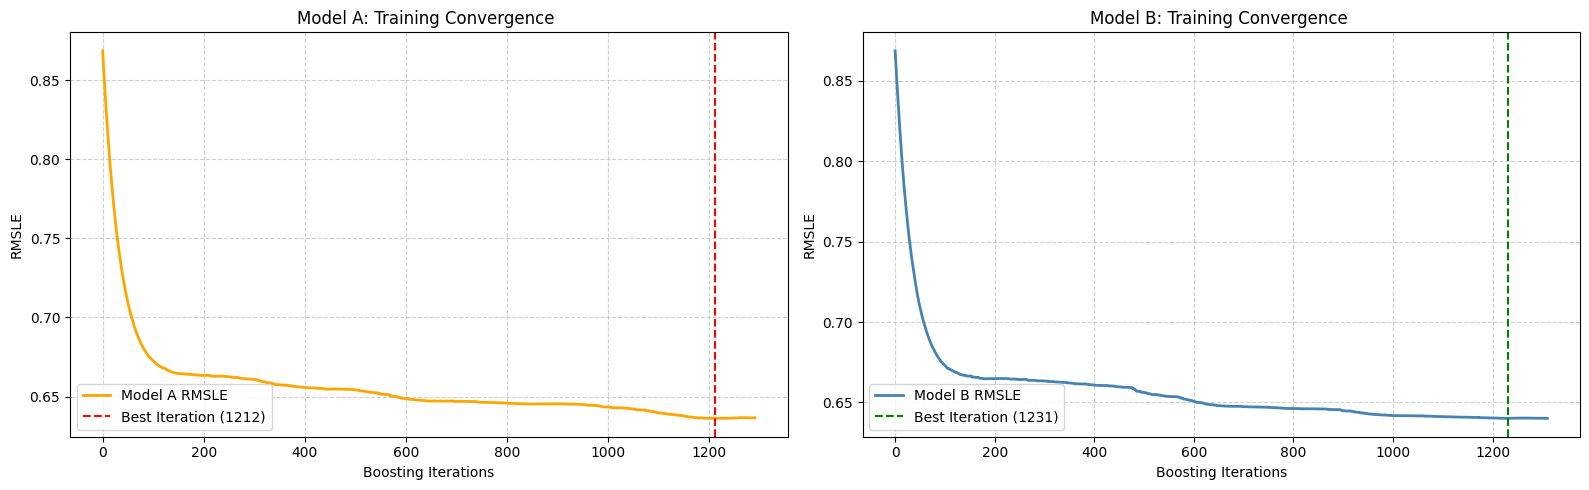

In [9]:
# 5. Create a figure with two subplots to compare Model A and Model B convergence
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Model A Convergence
axes[0].plot(pre_model_A.evals_result_['valid_0']['rmse'], label='Model A RMSLE', color='orange', linewidth=2)
axes[0].axvline(x=best_iters_A, color='red', linestyle='--', label=f'Best Iteration ({best_iters_A})')
axes[0].set_title('Model A: Training Convergence ')
axes[0].set_xlabel('Boosting Iterations')
axes[0].set_ylabel('RMSLE')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot Model B Convergence
axes[1].plot(pre_model_B.evals_result_['valid_0']['rmse'], label='Model B RMSLE', color='steelblue', linewidth=2)
axes[1].axvline(x=best_iters_B, color='green', linestyle='--', label=f'Best Iteration ({best_iters_B})')
axes[1].set_title('Model B: Training Convergence ')
axes[1].set_xlabel('Boosting Iterations')
axes[1].set_ylabel('RMSLE')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Figure 1: Comparative Analysis of Model Training Convergence (RMSLE)

Figure 1 illustrates the training convergence trajectories for Model A (Spatiotemporal baseline) and Model B (Weather-aware). Both models employ an early stopping mechanism to optimize generalization performance.

Model A (Left): Demonstrates stable convergence, with the optimal generalization achieved at iteration 1212.

Model B (Right): Shows a slightly extended learning phase, reaching the optimal state at iteration 1231. The incorporation of meteorological variables introduces additional complexity into the feature space, which influences the convergence behavior.

Metric: Both plots utilize the Root Mean Squared Logarithmic Error (RMSLE) as the evaluation metric, consistently applied across both models through the objective function on log-transformed target values.

## 6. Prediction Distribution Analysis
---
To ensure the robustness of the forecasting approach, the statistical distributions of the predicted bike availability for both models are analyzed. 

In [10]:
# 6. Evaluate and compare the descriptive statistics of the two models

print("[INFO] Analyzing prediction distributions for Model A and Model B...")

print(" \nModel A Prediction Statistics")
print(submission_A['bikes'].describe())

print("\nModel B Prediction Statistics")
print(submission_B['bikes'].describe())

[INFO] Analyzing prediction distributions for Model A and Model B...
 
Model A Prediction Statistics
count    537445.000000
mean          6.176943
std           3.457042
min           0.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          21.000000
Name: bikes, dtype: float64

Model B Prediction Statistics
count    537445.000000
mean          7.713865
std           4.705085
min           0.000000
25%           4.000000
50%           7.000000
75%          10.000000
max          30.000000
Name: bikes, dtype: float64


## 7. Model Interpretability: Feature Importance
---
To provide transparency into the decision-making processes of the gradient boosting models, the feature importance is quantified based on the total number of splits attributed to each feature. This analysis contrasts the baseline spatiotemporal features in Model A with the meteorologically augmented feature set in Model B, highlighting how external variables reshape the decision logic of the models.

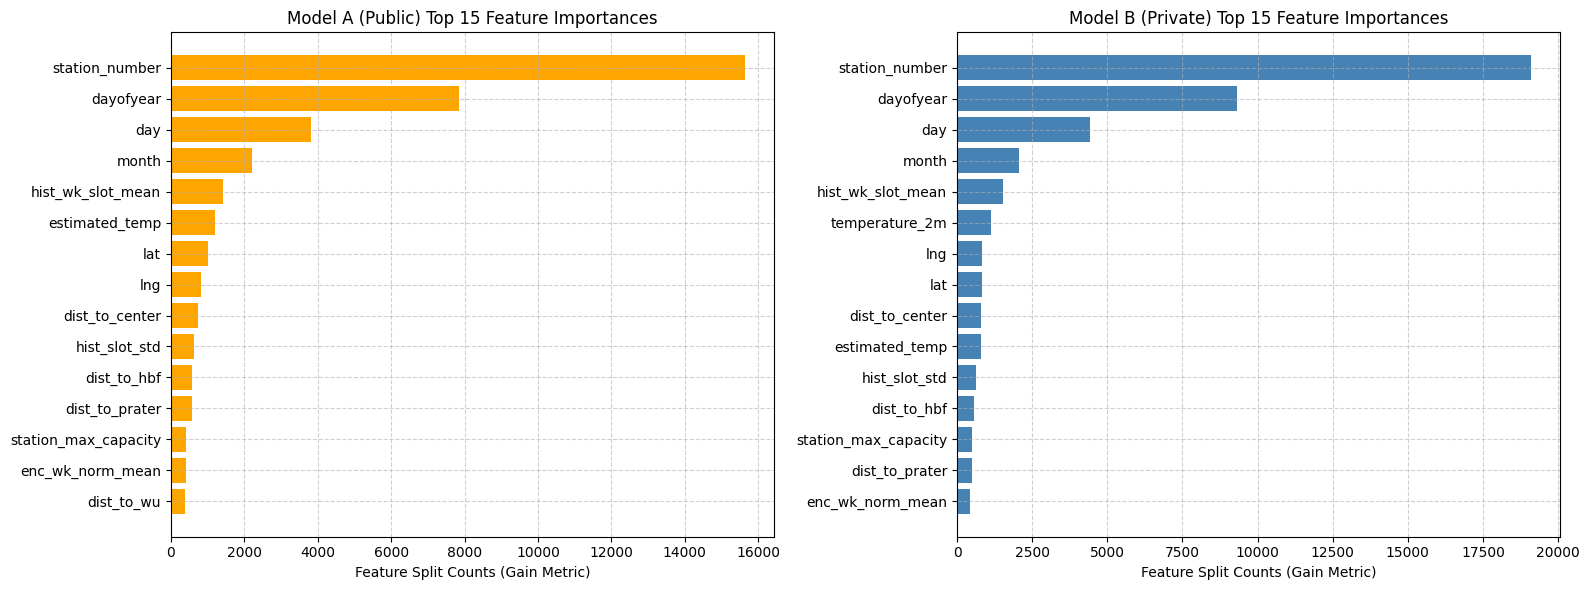

--- Decision Driver Audit Report ---
Primary driver for Model A: station_number (15649.0 splits)
Primary driver for Model B: station_number (19112.0 splits)


In [11]:
# 7.1 Extract feature importance for both models to audit decision-making logic

importance_A = pd.DataFrame({
    'Feature': X_train_A_full.columns,
    'Importance': model_A.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_B = pd.DataFrame({
    'Feature': X_train_B_full.columns,
    'Importance': model_B.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 7.2 Visualize comparative feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Model A
axes[0].barh(importance_A['Feature'].head(15)[::-1], importance_A['Importance'].head(15)[::-1], color='orange')
axes[0].set_title('Model A (Public) Top 15 Feature Importances')
axes[0].set_xlabel('Feature Split Counts (Gain Metric)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot for Model B
axes[1].barh(importance_B['Feature'].head(15)[::-1], importance_B['Importance'].head(15)[::-1], color='steelblue')
axes[1].set_title('Model B (Private) Top 15 Feature Importances')
axes[1].set_xlabel('Feature Split Counts (Gain Metric)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 6.3 Generate decision driver audit report
print("--- Decision Driver Audit Report ---")
print(f"Primary driver for Model A: {importance_A.iloc[0]['Feature']} ({importance_A.iloc[0]['Importance']:.1f} splits)")
print(f"Primary driver for Model B: {importance_B.iloc[0]['Feature']} ({importance_B.iloc[0]['Importance']:.1f} splits)")


Comparative Analysis of Feature Importance

Figure 2: Top 15 Feature Importances (Split Counts)

Figure 2 visualizes the feature importance for Model A and Model B, quantified by the number of times each feature is used for splitting decisions.

Core Drivers: In both models, station_number and temporal features (dayofyear, day) emerge as the primary decision drivers, confirming that spatial and temporal patterns are the fundamental determinants of bike demand.

Impact of Meteorological Integration: While Model A relies on estimated_temp, Model B demonstrates a more nuanced utilization of temperature_2m. The presence of both features in the top 15 indicates that the model successfully integrates climate variables to refine demand predictions during periods of high meteorological variability.

Structural Consistency: The ranking order remains relatively consistent across both models, validating the stability of the feature engineering pipeline. The shift in absolute split counts for station_number reflects the model's adaptation to the expanded dataset and feature space in Model B.

## 8. Global Model Explainability via TreeSHAP
---
To provide deeper insights into the non-linear dynamics of bike demand, TreeSHAP (SHAP values) is utilized to compute the marginal contribution of each feature to the model's predictions. This section contrasts the SHAP summary plots for Model A and Model B, elucidating how external weather features (Model B) interact with spatiotemporal patterns to influence the predicted bike availability.

[INFO] Initializing TreeSHAP explainer for global model transparency...


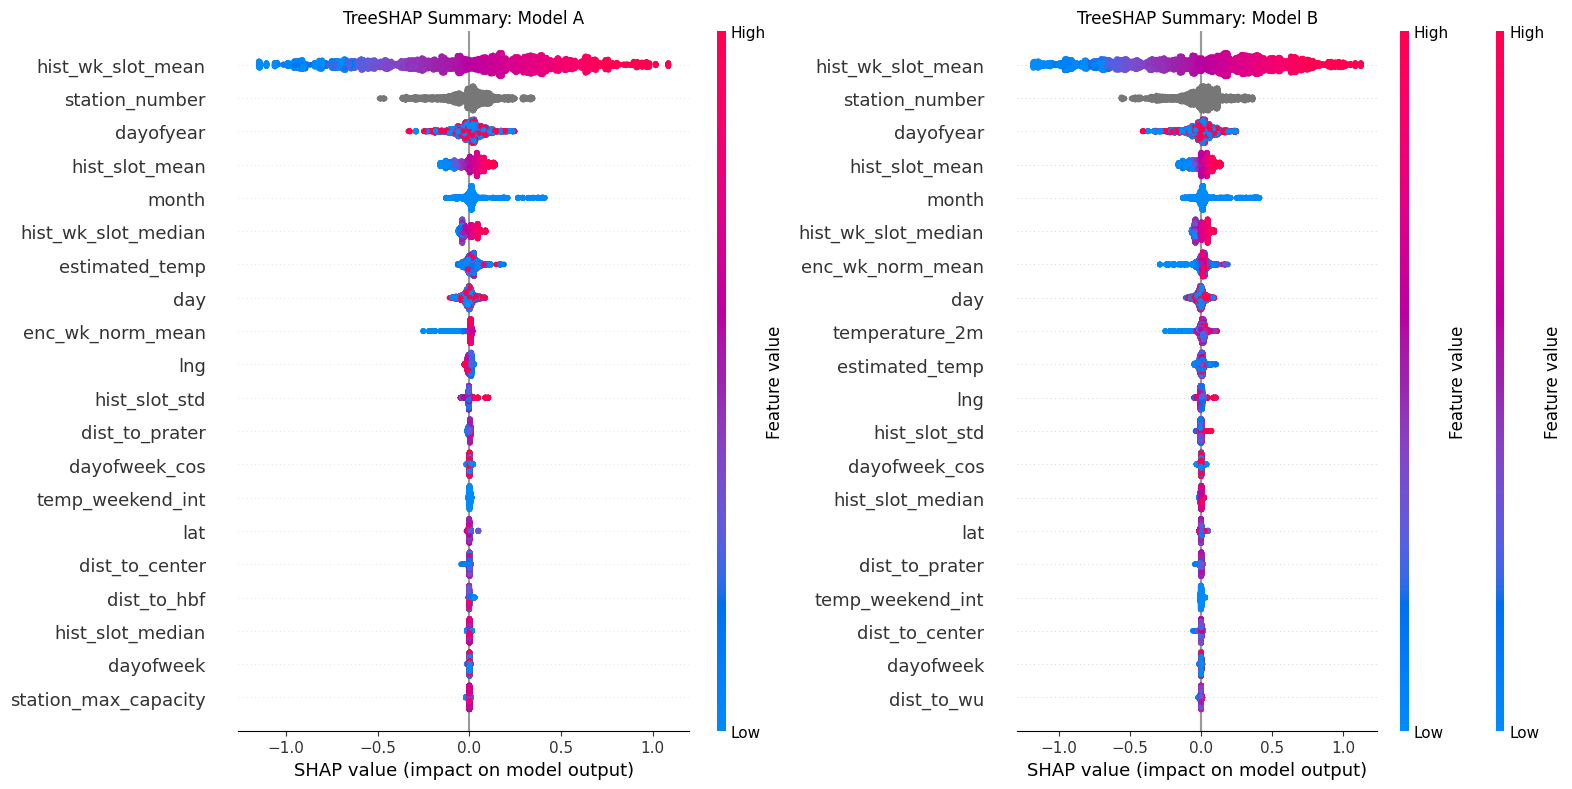

In [12]:
# 8.1 Initialize SHAP explainer for both models
print("[INFO] Initializing TreeSHAP explainer for global model transparency...")

# Use a representative subset of 5000 samples for efficient SHAP computation
shap_sample_A = X_va_A.head(5000)
shap_sample_B = X_va_B.head(5000)

explainer_A = shap.TreeExplainer(model_A)
explainer_B = shap.TreeExplainer(model_B)

shap_values_A = explainer_A(shap_sample_A)
shap_values_B = explainer_B(shap_sample_B)

# 8.2 Visualize SHAP summary plots for comparative analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

shap.summary_plot(shap_values_A, shap_sample_A, show=False, plot_size=None)

# Subplot for Model A
plt.sca(axes[0]) 
shap.summary_plot(shap_values_A, shap_sample_A, show=False, plot_size=None)
axes[0].set_title('TreeSHAP Summary: Model A')

# Subplot for Model B
plt.sca(axes[1])
shap.summary_plot(shap_values_B, shap_sample_B, show=False, plot_size=None)
axes[1].set_title('TreeSHAP Summary: Model B')

plt.tight_layout()
plt.show()

SHAP Global Interpretability Analysis

Figure 3: TreeSHAP Summary Plots for Model A and Model B

Figure 3 provides an in-depth interpretability analysis using TreeSHAP, revealing the marginal contribution of individual features to the model's output.

Dominant Predictors: Across both models, hist_wk_slot_mean (historical weekly slot mean) is the most significant positive predictor, indicating that historical usage patterns are the primary driver of current demand.

Non-Linear Dynamics: The SHAP plots demonstrate complex non-linear relationships, particularly for temporal features like dayofyear and month, where high feature values show both positive and negative impacts, reflecting seasonal cycle fluctuations.

Weather-Feature Impact (Model B): In Model B, the inclusion of temperature_2m provides a clear directional influence on predictions. The distribution of SHAP values for this feature suggests that the model effectively learns the thermal comfort threshold of users, refining demand estimates beyond the baseline established by estimated_temp in Model A.

Interpretability Conclusion: The consistency between the feature importance rankings (Figure 2) and SHAP values (Figure 3) validates the model's reliability, confirming that the predictions are driven by physically meaningful features rather than stochastic noise.

## 9. Conclusion
---
This study implements and evaluates two distinct LightGBM-based models to address the bike demand forecasting task. By exploring different feature sets focusing on spatiotemporal patterns and meteorological variables, the analysis assesses the influence of diverse inputs on model performance. These findings highlight the trade-offs between feature complexity and generalization, providing a framework for identifying robust strategies for urban mobility prediction.
